In [ ]:
import matplotlib.pyplot as plt
import os, re, shutil, string
import tensorflow as tf
import numpy as np

from tensorflow.keras import layers, losses

In [ ]:
url = 'https://github.com/Monirekhonsari/text-classification/raw/refs/heads/main/6-persian-topics.zip'

dataset = tf.keras.utils.get_file('6-persian-topics', url,
                                  extract=True, cache_dir='.',
                                  cache_subdir='')

dataset_dir = os.path.join(os.path.dirname(dataset),'/content/6-persian-topics/6-persian-topics')

16473431/16473431 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
os.listdir(dataset_dir)

['بهداشت و سلامت',
 'ریاضیات',
 'فناوری و علوم کاربردی و تکنولوژی',
 'جغرافیا و مکانها',
 'ورزش',
 'دین و اعتقاد']

In [ ]:
from pathlib import Path
for p in Path(dataset_dir).iterdir():
    print(("DIR " if p.is_dir() else "FILE"), p.resolve())


DIR  /content/6-persian-topics/6-persian-topics/بهداشت و سلامت
DIR  /content/6-persian-topics/6-persian-topics/ریاضیات
DIR  /content/6-persian-topics/6-persian-topics/فناوری و علوم کاربردی و تکنولوژی
DIR  /content/6-persian-topics/6-persian-topics/جغرافیا و مکانها
DIR  /content/6-persian-topics/6-persian-topics/ورزش
DIR  /content/6-persian-topics/6-persian-topics/دین و اعتقاد


In [ ]:
sample_file = os.path.join(dataset_dir, 'دین و اعتقاد/1079280.txt')
with open(sample_file) as f:
  print(f.read())

بئاتیفیه (به انگلیسی: beatification) اعلام رسمی ورود شخص مرده به بهشت از جانب کلیسای کاتولیک و توانایی او به شفاعت برای کسانی است که به نام او دعا کنند.


هر بار ۳۲ نمونه را در یک دسته به مدل می‌دهد



In [ ]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    dataset_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
     shuffle=True,              # ترتیب فایل‌ها را مخلوط کن
    labels='inferred',         # برچسب از نام پوشه
    label_mode='int',          # خروجی برچسب‌ها عدد صحیح است
    seed=seed)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    dataset_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
     shuffle=True,              # ترتیب فایل‌ها را مخلوط کن
    labels='inferred',         # برچسب از نام پوشه
    label_mode='int',          # خروجی برچسب‌ها عدد صحیح است
    seed=seed)

Found 37573 files belonging to 6 classes.
Using 30059 files for training.
Found 37573 files belonging to 6 classes.
Using 7514 files for validation.


In [ ]:
for label in range(6):
  print('Label {} corresponds to {}'. format(label, raw_train_ds.class_names[label]))

Label 0 corresponds to بهداشت و سلامت
Label 1 corresponds to جغرافیا و مکانها
Label 2 corresponds to دین و اعتقاد
Label 3 corresponds to ریاضیات
Label 4 corresponds to فناوری و علوم کاربردی و تکنولوژی
Label 5 corresponds to ورزش


In [ ]:
for text, label in raw_train_ds.take(1):
  for i in range(10):
    print("Review", text.numpy()[i].decode()) #use decode for persian text
    print("Label", label.numpy()[i])

Review آافیر (به لاتین: Aafir) در الجزایر با جمعیت ۱۲٬۶۱۳ نفر است که در استان بومرداس واقع شده‌است.
Label 1
Review نبردناو کلاس مونتانا (به انگلیسی: Montana-class battleship) یک کلاس از کشتی است که طول آن ۹۲۰ فوت ۶ اینچ (۲۸۰٫۵۷ متر) می‌باشد.
Label 4
Review کن فِم (به آلمانی: KenFM)، یک پایگاه خبری تحلیلی آلمانی است.
Label 4
Review شهرستان آدامز، کلرادو (به انگلیسی: Adams County, Colorado) یک سکونتگاه مسکونی در ایالات متحده آمریکا است که در کلرادو واقع شده‌است.
Label 1
Review موشان (به لاتین: Mosjøen) (تلفظ نروژی: [ˈmu:ʃøn] گوش‌دادن ) یک شهرک در نروژ است که در وفسن واقع شده‌است. موشان ۶٫۴۱ کیلومتر مربع مساحت و ۹٬۶۶۵ نفر جمعیت دارد.
Label 1
Review سیداد کولونیالاین مکان در سال ۱۹۹۰ در میراث جهانی یونسکو به ثبت رسید.
Label 1
Review ایران از ۱۸ اوت تا ۲ سپتامبر ۲۰۱۸ در بازی‌های آسیایی ۲۰۱۸ در جاکارتا و پالم‌بانگ اندونزی شرکت کرد. ایران از اولین دوره بازی‌ها در دهلی‌نو ۱۹۵۱ در بازی‌های آسیایی شرکت کرده‌است و بهترین دستاورد ایران در سال ۱۹۷۴ بود، زمانی که ایران میزبان این بازی‌ها بود. در تهر

tf.keras.utils.text_dataset_from_directory یک تابع آماده‌ی  است که از روی پوشه‌ها فایل‌های متنی را می‌خواند و یک    دیتاست می‌سازد


 برچسب‌ها را از نام پوشه‌ها حدس می‌زند

 دقیقاً یک‌بار اجرا می‌شود و text و label همان اولین بَچ هستند

In [ ]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', '')
  stripped_ye = tf.strings.regex_replace(stripped_html, 'ي', 'ی')
  return tf.strings.regex_replace(stripped_ye, '[%s]' % re.escape(string.punctuation),'')

In [ ]:
txt = ('براي <br />برای')
print(custom_standardization(txt).numpy().decode())

برای برای


این کد یک لایهٔ بردارسازی

 میسازد kerasمتن در  
تا متن خام را به دنباله‌ای از اعداد تبدیل کند که بتوان آن را به مدل داد    
        

In [ ]:
max_features = 20000
sequence_length = 250

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [ ]:
train_text = raw_train_ds.map(lambda x,y:x)
vectorize_layer.adapt(train_text)

فقط متن را نگه می‌داری

واژگان را یاد بگیر train از روی متن‌های

بعد از این مرحله، هر متن خام را به «دنباله‌ی اعداد با طول ثابت» تبدیل می‌کند و آماده‌ی ورود به مدل است

In [ ]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label


«expand_dims» : یک بُعد جدید به انتهای تانسور اضافه کن

فقظ یک رشته باشد text فرض کن

text.shape == () --> انتظار دارد ورودی‌اش حداقل 1 بعد داشته باشد

(مثل [ "سلام!" ]

نه "سلام!")

پس با tf.expand_dims(text, -1) --->

text.shape == (1,)

فقط باعث می‌شود ورودی برای لایه‌ی بعدی قابل‌خواندن و سازگار شود

In [ ]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review.numpy().decode())
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review شبه‌جزیره چهارکان (روسی: Челекен полуостров) (نام‌های دیگر: چله‌کن، نفتونیا، جزیره نفت) شبه‌جزیره‌ای است در غرب ترکمنستان، در سواحل شرقی دریای خزر. شهر خزر (چهارکان سابق) در این شبه‌جزیره واقع شده‌است که از لحاظ اداری به استان بلخان ترکمنستان تعلق دارد.
Label جغرافیا و مکانها
Vectorized review (<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[ 1343,     1,   235,     1,     1,   913,   123,     1,     1,
          178,  1761,  9178,     5,     2,   137, 12529,     2,  1926,
          110,   254,  3000,    22,  3000,     1,  1026,     2,     8,
         1343,    10,    11,     6,     7,  1454,   599,     3,    25,
         8473,  1192,  3452,    18,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
          

In [ ]:
print('1237--->', vectorize_layer.get_vocabulary()[1237])
print('313--->', vectorize_layer.get_vocabulary()[313])
print('vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1237---> بالاترین
313---> روستا
vocabulary size: 20000


In [ ]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)

این دو خط، دیتاست‌های خامت (raw_train_ds و raw_val_ds)

را با تابعی که ساختی (vectorize_text)

پیش‌پردازش می‌کنند و خروجیِ آماده‌ی مدل می‌سازند


***Configure the dataset for performance (بهینه‌سازی سرعت لولهٔ داده‌ها)***


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

این‌ها دو روش مهم هستند که هنگام بارگذاری داده‌ها باید از آن‌ها استفاده کنید تا مطمئن شوید عملیات ورودی/خروجی مسدودکننده نمی‌شود

cache():

داده‌ها را پس از بارگذاری از دیسک در حافظه نگه می‌دارد. این اطمینان را می‌دهد که مجموعه داده در حین آموزش مدل شما به یک گلوگاه تبدیل نشود. اگر مجموعه داده شما خیلی بزرگ است و در حافظه جا نمی‌شود، می‌توانید از این روش برای ایجاد یک کش روی دیسک با عملکرد بالا نیز استفاده کنید، که خواندن آن نسبت به فایل‌های کوچک متعدد کارآمدتر است

prefetch():

پیش‌پردازش داده‌ها و اجرای مدل را در حین آموزش همزمان می‌کند.شما می‌توانید درباره هر دو روش و همچنین نحوه کش کردن داده‌ها روی دیسک، در راهنمای عملکرد داده‌ها اطلاعات بیشتری کسب کنید

AUTOTUNE : اجازه می‌دهد بهترین اندازهٔ بافر را خودش انتخاب کنه TensorFlow به

-----------------------------------------------------------------

### Create the model

It's time to create your neural network:

In [ ]:
embedding_dim = 16

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), dtype='int32'),
    # هر نمونه یک دنباله‌ی عددی با طول متغیر
    tf.keras.layers.Embedding(max_features, embedding_dim),
    # واقع یک جدول 10000×16 دارد که هر سطرش یک کلمه را نمایش می‌دهد
    tf.keras.layers.GlobalAveragePooling1D(),
    # این لایه بردارهای تمام توکن‌های جمله را میانگین‌گیری می‌کند
    #  های جمله را جمع کرده و بر طول جمله تقسیم می‌کند embedding
    tf.keras.layers.Dense(100, activation='relu'),
    # activation='relu' : باعث می‌شود فقط مقادیر مثبت عبور کنند
    tf.keras.layers.Dropout(0.5),
    # ( overfitting جلوگیری از ) در طول آموزش، به‌صورت تصادفی ۵۰٪ از نودها را غیرفعال می‌کند
    tf.keras.layers.Dense(6)
])
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, None, 16)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,306 (1.23 MB)

 Trainable params: 322,306 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

رفتار کلی مدل

کلمه‌ها → تبدیل به بردار (Embedding)

بردارها → میانگین‌گیری برای جمله (Pooling)

جمله → استخراج ویژگی (Dense 100)

حذف تصادفی نودها برای تنظیم‌گری (Dropout)

تولید احتمال ۶ کلاس (Dense 6)

Overfitting یعنی مدل شما داده‌های آموزشی را بیش از حد یاد می‌گیرد — تا جایی که حتی نویز، اشتباه‌ها و جزئیات تصادفی داده را هم حفظ می‌کند
نتیجه: مدل روی داده‌های آموزش عالی عمل می‌کند، اما روی داده‌های جدید خیلی بد

مدل به جای اینکه الگوها را یاد بگیرد، داده‌های تمرین را حفظ کرده است

### ***Loss function and optimizer***

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

Adam :  پرکاربردترین و قدرتمندترین الگوریتم‌های بهینه‌سازی است


برای هر وزن جداگانه نرخ یادگیری مخصوص تنظیم می‌کند، بر اساس اینکه گرادیانش چقدر زیاد یا کم است


### Train the model

You will train the model by passing the `dataset` object to the fit method

In [ ]:
epochs = 15
# epoch :(اینجا مدل ۱۵ بار کل دادهٔ آموزش رو می‌بیند)train_ds یعنی یک بار عبور کامل از تمام نمونه‌های

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5983 - loss: 1.1578 - val_accuracy: 0.8817 - val_loss: 0.4213
Epoch 2/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8705 - loss: 0.4059 - val_accuracy: 0.9039 - val_loss: 0.2694
Epoch 3/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9091 - loss: 0.2756 - val_accuracy: 0.9402 - val_loss: 0.1898
Epoch 4/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9360 - loss: 0.2037 - val_accuracy: 0.9485 - val_loss: 0.1585
Epoch 5/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9497 - loss: 0.1605 - val_accuracy: 0.9577 - val_loss: 0.1348
Epoch 6/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9594 - loss: 0.1325 - val_accuracy: 0.9609 - val_loss: 0.1244
Epoch 7/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9643 - loss: 0.1116 - val_accuracy: 0.9602 - val_loss: 0.1293
Epoch 8/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9700 - loss: 0.0968 - val_accuracy: 

### Create a plot of accuracy and loss over time

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

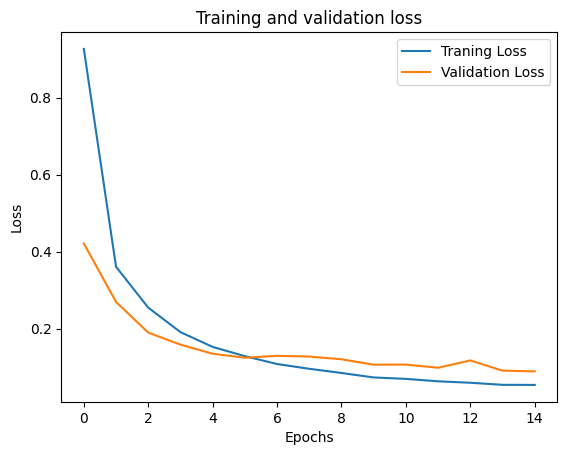

In [ ]:
plt.plot(loss, label='Traning Loss')

plt.plot(val_loss, label='Validation Loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

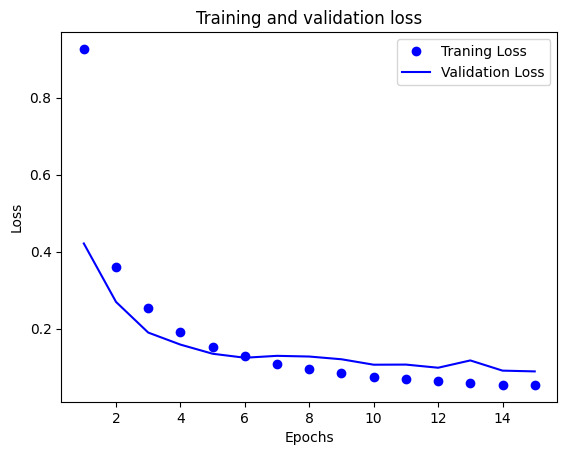

In [ ]:
epochs = range(1, len(acc) + 1)
# که مدل آموزش دیده epoches توالی از اعداد ۱ تا تعداد

plt.plot(epochs,loss, 'bo', label='Traning Loss')

plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

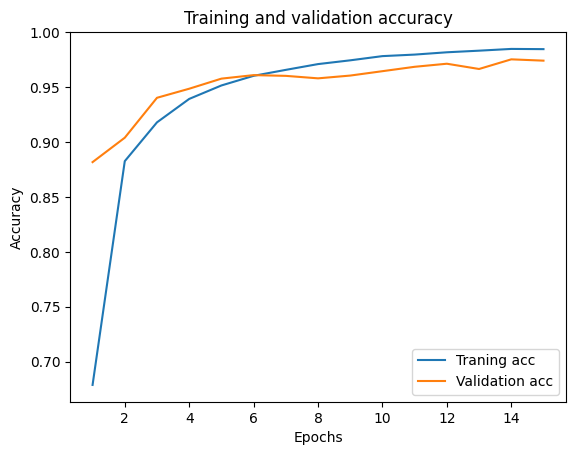

In [ ]:
plt.plot(epochs,acc, label='Traning acc')

plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

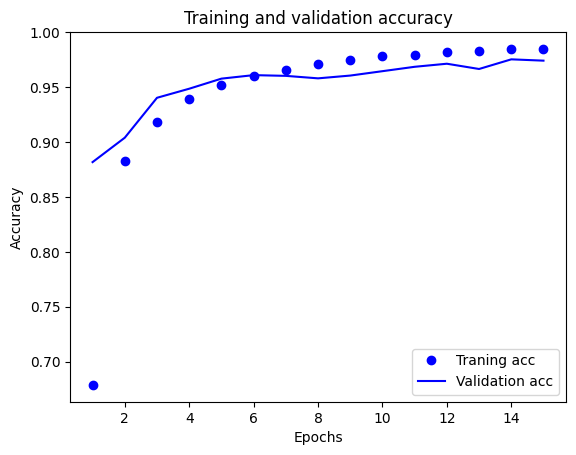

In [ ]:
epochs = range(1, len(acc) + 1)

plt.plot(epochs,acc, 'bo', label='Traning acc')

plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### ***Export the model***

In [ ]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('softmax') # خروجی: probabilities(احتمال هر کلاس)
])

export_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

loss, accuracy = export_model.evaluate(raw_val_ds)
print(accuracy)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9747 - loss: 0.0826
0.9740484356880188


In [ ]:

examples = np.array([
  "ویروس کرونا جان خیلی ها را گرفت",
  "فوتبال نوجوانان کشور با نتیجه 2 بر 0 به پایان رسید.",
  "تهران پایخت ایران است."
])
p = export_model.predict(examples)
results = np.argmax(p, axis=1)
# برای هر نمونه، اندیسِ کلاس با بیشترین احتمال را برمی‌گرداند

for r in results:
  print(raw_train_ds.class_names[r])
# لیست نام کلاس‌هاست



ValueError: Invalid dtype: str1632

In [ ]:
examples = tf.constant([
  "ویروس کرونا جان خیلی ها را گرفت",
  "فوتبال نوجوانان کشور با نتیجه 2 بر 0 به پایان رسید.",
  "تهران پایتخت ایران است."
])

p = export_model.predict(examples)
results = np.argmax(p, axis=1)

for r in results:
    print(raw_train_ds.class_names[r])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
جغرافیا و مکانها
ورزش
جغرافیا و مکانها


### ***Confusion matrix(ماتریس درهم ریختگی)*** :  اشتباه‌ یابیِ دقیق

مدل در هر کلاس چند تا درست و چند تا اشتباه پیش‌بینی کرده است

وقتی دقت کلی خوب نیست → ببینی اشتباه‌ها کجا متمرکزند

وقتی دقت کلی خوب است → مطمئن شوی همهٔ کلاس‌ها خوب‌اند، نه اینکه یک کلاس به شده باشد

In [ ]:
# # جدا کردن ورودی‌ها (ویژگی‌ها) و برچسب‌ها (labels)
features = raw_val_ds.map(lambda x, y: x)
labels = raw_val_ds.map(lambda x, y: y)

# پیش‌بینی مدل
predictions = export_model.predict(features)

# تبدیل احتمال‌ها به کلاس نهایی
predicted_classes = tf.math.argmax(predictions, axis=-1)

# استخراج برچسب‌های واقعی از دیتاست
labels_list = list(labels.as_numpy_iterator())

# یکی کردن تمام دسته ها در یک آرایه
labels = np.concatenate(labels_list, axis=0)

# ساخت ماتریس درهم‌ریختگی
confusion_mtx = tf.math.confusion_matrix(labels, predicted_classes)

# خروجی
confusion_mtx

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<tf.Tensor: shape=(6, 6), dtype=int32, numpy=
array([[  22,  228,    6,    1,   69,   56],
       [ 215, 2642,   68,   33,  758,  720],
       [   8,   64,    1,    3,   21,   12],
       [   4,   35,    0,    0,   12,   10],
       [  68,  803,   21,   11,  203,  209],
       [  62,  705,   16,   20,  207,  201]], dtype=int32)>

In [ ]:
!pip install python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install arabic_reshaper

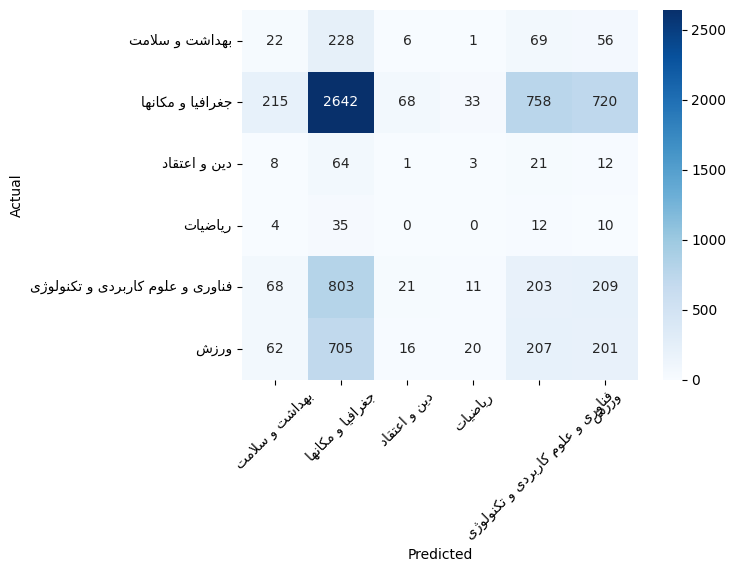

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display

def convert_text(t):
    reshaped_text = arabic_reshaper.reshape(t) # seperated chars problem
    bidi_text = get_display(reshaped_text) #direction problem
    text = bidi_text.encode().decode('utf-8') #encoding problem (rectangular boxes!)
    return text

class_names = [convert_text(t) for t in raw_train_ds.class_names]

sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(np.arange(len(class_names))+0.5, class_names, rotation=45)
plt.yticks(np.arange(len(class_names))+0.5, class_names, rotation=0)

plt.show()

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_classes)

for i in range(6):
  print("Label {} corresponds to {}".format(i, raw_train_ds.class_names[i]))
print(report)

Label 0 corresponds to بهداشت و سلامت
Label 1 corresponds to جغرافیا و مکانها
Label 2 corresponds to دین و اعتقاد
Label 3 corresponds to ریاضیات
Label 4 corresponds to فناوری و علوم کاربردی و تکنولوژی
Label 5 corresponds to ورزش
              precision    recall  f1-score   support

           0       0.06      0.06      0.06       382
           1       0.59      0.60      0.59      4436
           2       0.01      0.01      0.01       109
           3       0.00      0.00      0.00        61
           4       0.16      0.15      0.16      1315
           5       0.17      0.17      0.17      1211

    accuracy                           0.41      7514
   macro avg       0.16      0.16      0.16      7514
weighted avg       0.41      0.41      0.41      7514

